# 🧪 Deep Learning Experiment Notebook
## Sign Language MNIST — Model Comparison

**Baseline reference:** Baseline CNN → Test Loss: 0.0472 | Test Acc: **99.36%** (~442K params)

### Available Models (change `MODEL_NAME` in Cell 2)
| # | `MODEL_NAME` | Architecture | Key Idea |
|---|---|---|---|
| 0 | `baseline_cnn` | 3-block Conv (your original) | Reference |
| 1 | `residual_cnn` | ResNet-style skip connections | Vanishing gradient fix |
| 2 | `depthwise_cnn` | MobileNet-style depthwise separable | Lightweight / fast |
| 3 | `inception_cnn` | Multi-scale parallel convolutions | Wider receptive field |
| 4 | `se_cnn` | Squeeze-and-Excitation (channel attention) | Feature recalibration |
| 5 | `densenet_cnn` | DenseNet-style dense connections | Feature reuse |
| 6 | `mobilenetv2_transfer` | MobileNetV2 pretrained (ImageNet) | Transfer learning |

Everything else (data pipeline, augmentation, callbacks, evaluation plots) is **identical** across all models, so results are directly comparable.

In [1]:
# ── 0. Imports ────────────────────────────────────────────
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, Model
from tensorflow.keras.applications import MobileNetV2

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}\n")

TensorFlow  : 2.21.0
GPU available: False



In [2]:
# ── 1. ✏️  CHANGE THIS to switch models ──────────────────
#
#   'baseline_cnn'        — your original 3-block CNN
#   'residual_cnn'        — ResNet-style residual blocks
#   'depthwise_cnn'       — MobileNet depthwise separable
#   'inception_cnn'       — multi-scale Inception module
#   'se_cnn'              — Squeeze-and-Excitation attention
#   'densenet_cnn'        — DenseNet dense connections
#   'mobilenetv2_transfer'— pretrained MobileNetV2 (needs 32x32+ & 3ch)

MODEL_NAME = "mobilenetv2_transfer"   # <── change me

# ── Hyperparameters & Paths ───────────────────────────────
TRAIN_CSV   = "Dataset/sign_mnist_train/sign_mnist_train.csv"
TEST_CSV    = "Dataset/sign_mnist_test/sign_mnist_test.csv"

OUTPUT_DIR  = f"outputs/{MODEL_NAME}"
LOG_DIR     = f"logs/{MODEL_NAME}"
IMG_SIZE    = 28
CHANNELS    = 1
NUM_CLASSES = 24
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 1e-3
SEED        = 42

# MobileNetV2 transfer needs RGB 32×32+
TRANSFER    = (MODEL_NAME == "mobilenetv2_transfer")
if TRANSFER:
    IMG_SIZE  = 32
    CHANNELS  = 3

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Model selected : {MODEL_NAME}")
print(f"Output dir     : {OUTPUT_DIR}")

Model selected : mobilenetv2_transfer
Output dir     : outputs/mobilenetv2_transfer


In [3]:
# ── 2. Load & Pre-process Data ────────────────────────────
def load_data(path, img_size=28, channels=1):
    df     = pd.read_csv(path)
    labels = df["label"].values.astype(np.int32)
    pixels = df.drop("label", axis=1).values.astype(np.float32) / 255.0
    images = pixels.reshape(-1, 28, 28, 1)          # always load as 28x28x1 first

    if img_size != 28 or channels != 1:
        # Resize and convert to RGB for transfer learning
        images = tf.image.resize(images, [img_size, img_size]).numpy()
        if channels == 3:
            images = np.repeat(images, 3, axis=-1)  # grayscale → pseudo-RGB
    return images, labels

print("Loading data …")
X_train, y_train = load_data(TRAIN_CSV, IMG_SIZE, CHANNELS)
X_test,  y_test  = load_data(TEST_CSV,  IMG_SIZE, CHANNELS)

LABEL_MAP   = {v: i for i, v in enumerate(sorted(set(y_train)))}
CLASS_NAMES = [chr(ord("A") + k) for k in sorted(LABEL_MAP.keys())
               if chr(ord("A") + k) not in ("J", "Z")]

y_train_idx = np.array([LABEL_MAP[l] for l in y_train])
y_test_idx  = np.array([LABEL_MAP[l] for l in y_test])

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Loading data …
Train : (27455, 32, 32, 3)  |  Test : (7172, 32, 32, 3)
Classes (24): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [4]:
# ── 3. Data Augmentation Pipeline (same for all models) ───
augment_layer = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.10),
    layers.RandomFlip("horizontal"),
], name="augmentation")

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
        ds = ds.map(lambda x, l: (augment_layer(x, training=True), l),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_idx, training=True)
val_ds   = make_dataset(X_test,  y_test_idx,  training=False)
print("Datasets ready.")

Datasets ready.


In [5]:
# ── 4. Model Definitions ───────────────────────────────────

# ─────────────────────────────────────────────────────────
# MODEL 0 — Baseline CNN (your original, kept for reference)
# ─────────────────────────────────────────────────────────
def build_baseline_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32,  (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,  (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Baseline_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 1 — Residual CNN  (ResNet-style)
# Idea: add shortcut (skip) connections so gradients flow
#       directly; lets the model learn residuals F(x)+x.
# ─────────────────────────────────────────────────────────
def residual_block(x, filters, stride=1):
    """Pre-activation residual block."""
    shortcut = x
    # Projection shortcut when shape changes
    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), strides=stride, padding="same")(x)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, (3,3), strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, (3,3), padding="same")(x)
    x = layers.Add()([x, shortcut])
    return x

def build_residual_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same")(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, stride=2)  # 28→14
    x = layers.Dropout(0.25)(x)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2) # 14→7
    x = layers.Dropout(0.25)(x)
    x = residual_block(x, 128)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Residual_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 2 — Depthwise Separable CNN  (MobileNet-style)
# Idea: replace standard Conv with depthwise + pointwise.
#       Same receptive field, ~8-9× fewer multiply-adds.
# ─────────────────────────────────────────────────────────
def dw_block(x, filters, strides=1, dropout=0.25):
    x = layers.DepthwiseConv2D((3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (1,1), strides=strides, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    if strides > 1:
        x = layers.Dropout(dropout)(x)
    return x

def build_depthwise_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)

    x = dw_block(x, 32)
    x = dw_block(x, 64,  strides=2)   # 28→14
    x = dw_block(x, 64)
    x = dw_block(x, 128, strides=2)   # 14→7
    x = dw_block(x, 128)
    x = dw_block(x, 256, strides=2)   # 7→3

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Depthwise_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 3 — Inception CNN  (multi-scale)
# Idea: each module runs 1×1, 3×3, 5×5 convolutions in
#       parallel and concatenates — captures fine & coarse
#       texture at once.
# ─────────────────────────────────────────────────────────
def inception_module(x, f1, f3, f5):
    branch1 = layers.Conv2D(f1, (1,1), padding="same", activation="relu")(x)
    branch1 = layers.BatchNormalization()(branch1)

    branch3 = layers.Conv2D(f3//2, (1,1), padding="same", activation="relu")(x)
    branch3 = layers.Conv2D(f3,    (3,3), padding="same", activation="relu")(branch3)
    branch3 = layers.BatchNormalization()(branch3)

    branch5 = layers.Conv2D(f5//2, (1,1), padding="same", activation="relu")(x)
    branch5 = layers.Conv2D(f5,    (5,5), padding="same", activation="relu")(branch5)
    branch5 = layers.BatchNormalization()(branch5)

    pool_b  = layers.MaxPooling2D((3,3), strides=1, padding="same")(x)
    pool_b  = layers.Conv2D(f1, (1,1), padding="same", activation="relu")(pool_b)

    return layers.Concatenate()([branch1, branch3, branch5, pool_b])

def build_inception_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)                              # 28→14

    x = inception_module(x, f1=16, f3=32, f5=16)             # 64-ch out
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x) # 14→7

    x = inception_module(x, f1=32, f3=64, f5=32)             # 128-ch out
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x) # 7→3

    x = inception_module(x, f1=64, f3=128, f5=64)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Inception_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 4 — SE-CNN  (Squeeze-and-Excitation)
# Idea: after each conv block, a small sub-network
#       'squeezes' spatial info into a channel descriptor
#       and 'excites' (rescales) useful channels.
#       Adds ~only 2×(C²/r) params per block.
# ─────────────────────────────────────────────────────────
def se_block(x, ratio=8):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)         # squeeze
    s = layers.Dense(c // ratio, activation="relu")(s)
    s = layers.Dense(c, activation="sigmoid")(s)   # excitation
    s = layers.Reshape((1, 1, c))(s)
    return layers.Multiply()([x, s])               # recalibrate

def se_conv_block(x, filters, dropout=0.25):
    x = layers.Conv2D(filters, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)                    # channel attention
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout)(x)
    return x

def build_se_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = se_conv_block(inp, 32)
    x = se_conv_block(x,  64)
    x = se_conv_block(x, 128)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x); x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="SE_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 5 — DenseNet-style CNN
# Idea: each layer receives feature maps from ALL preceding
#       layers — maximal feature reuse, fewer parameters.
# ─────────────────────────────────────────────────────────
def dense_block(x, num_layers, growth_rate):
    """Each layer adds `growth_rate` new channels."""
    feature_list = [x]
    for _ in range(num_layers):
        z = layers.Concatenate()(feature_list) if len(feature_list) > 1 else feature_list[0]
        z = layers.BatchNormalization()(z); z = layers.Activation("relu")(z)
        z = layers.Conv2D(growth_rate, (3,3), padding="same")(z)
        feature_list.append(z)
    return layers.Concatenate()(feature_list)

def transition_block(x, compression=0.5):
    out_ch = max(1, int(x.shape[-1] * compression))
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(out_ch, (1,1), padding="same")(x)
    x = layers.AveragePooling2D()(x)
    return x

def build_densenet_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same")(inp)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 28×28
    x = transition_block(x)                            # 14×14
    x = layers.Dropout(0.25)(x)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 14×14
    x = transition_block(x)                            # 7×7
    x = layers.Dropout(0.25)(x)

    x = dense_block(x, num_layers=4, growth_rate=16)  # 7×7
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="DenseNet_CNN")


# ─────────────────────────────────────────────────────────
# MODEL 6 — MobileNetV2  (Transfer Learning)
# Idea: ImageNet-pretrained backbone; only the new head
#       is trained at first, then we fine-tune top layers.
# NOTE: requires IMG_SIZE=32, CHANNELS=3 (set automatically
#       when MODEL_NAME='mobilenetv2_transfer').
# ─────────────────────────────────────────────────────────
def build_mobilenetv2_transfer(input_shape, num_classes):
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    # Phase 1: freeze all backbone layers
    base.trainable = False

    inp = layers.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.40)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    m   = Model(inp, out, name="MobileNetV2_Transfer")
    return m, base   # return base so we can unfreeze later


# ── Model Dispatcher ──────────────────────────────────────
input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS)
mobilenet_base = None

dispatch = {
    "baseline_cnn":         build_baseline_cnn,
    "residual_cnn":         build_residual_cnn,
    "depthwise_cnn":        build_depthwise_cnn,
    "inception_cnn":        build_inception_cnn,
    "se_cnn":               build_se_cnn,
    "densenet_cnn":         build_densenet_cnn,
}

if MODEL_NAME == "mobilenetv2_transfer":
    model, mobilenet_base = build_mobilenetv2_transfer(input_shape, NUM_CLASSES)
elif MODEL_NAME in dispatch:
    model = dispatch[MODEL_NAME](input_shape, NUM_CLASSES)
else:
    raise ValueError(f"Unknown MODEL_NAME: '{MODEL_NAME}'. "
                     f"Choose from: {list(dispatch.keys()) + ['mobilenetv2_transfer']}")

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# ── 5. Compile ────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
# ── 6. Callbacks ──────────────────────────────────────────
cb_list = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, "best_model.keras"),
        monitor="val_accuracy", save_best_only=True, verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1,
    ),
    callbacks.TensorBoard(log_dir=LOG_DIR, histogram_freq=1),
]
print("Callbacks ready.")

Callbacks ready.


In [8]:
# ── 7. Train ──────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=cb_list,
)

# ── Fine-tune transfer model (Phase 2) ───────────────────
# Unfreeze the top 40 layers of MobileNetV2 and re-train
# at a low LR to let the backbone adapt to sign language.
if MODEL_NAME == "mobilenetv2_transfer" and mobilenet_base is not None:
    print("\n─── Phase 2: Fine-tuning top MobileNetV2 layers ───")
    mobilenet_base.trainable = True
    # Freeze all but the last 40 layers
    for layer in mobilenet_base.layers[:-40]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_ft = model.fit(
        train_ds, epochs=10,
        validation_data=val_ds,
        callbacks=cb_list,
    )
    print("Fine-tuning complete.")

Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1470 - loss: 2.9174
Epoch 1: val_accuracy improved from None to 0.24108, saving model to outputs/mobilenetv2_transfer/best_model.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.1968 - loss: 2.7303 - val_accuracy: 0.2411 - val_loss: 2.5316 - learning_rate: 0.0010
Epoch 2/30
425/429 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2527 - loss: 2.4834
Epoch 2: val_accuracy did not improve from 0.24108
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2588 - loss: 2.4546 - val_accuracy: 0.2317 - val_loss: 2.5066 - learning_rate: 0.0010
Epoch 3/30
428/429 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2727 - loss: 2.3879
Epoch 3: val_accuracy improved from 0.24108 to 0.24205, saving model to outputs/mobilenetv2_transfer/best_model.keras
429/429 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2762 - loss: 2.3783 - val_accuracy: 0.2421 - val_loss: 2.4840 - learning_rate: 0.0010
Epoch 4/30
427/429 ━━━━━━━━━

In [9]:
# ── 8. Evaluate ───────────────────────────────────────────
print(f"\n── Evaluation [{MODEL_NAME}] ─────────────────────────")
loss, acc = model.evaluate(X_test, y_test_idx, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc * 100:.2f}%\n")

print(f"[Baseline reference] Loss: 0.0472 | Acc: 99.36%")
delta = (acc * 100) - 99.36
sign  = "+" if delta >= 0 else ""
print(f"Delta vs baseline     : {sign}{delta:.2f}%\n")

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test_idx, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))


── Evaluation [mobilenetv2_transfer] ─────────────────────────
Test Loss     : 15.2501
Test Accuracy : 12.38%

[Baseline reference] Loss: 0.0472 | Acc: 99.36%
Delta vs baseline     : -86.98%

              precision    recall  f1-score   support

           A     0.1067    0.3474    0.1632       331
           B     0.0000    0.0000    0.0000       432
           C     1.0000    0.0032    0.0064       310
           D     0.0000    0.0000    0.0000       245
           E     0.4954    0.1084    0.1779       498
           F     0.0920    0.4332    0.1518       247
           G     0.1929    0.2644    0.2230       348
           H     0.1515    0.0115    0.0213       436
           I     0.6346    0.1146    0.1941       288
           K     0.0000    0.0000    0.0000       331
           L     0.0934    0.5072    0.1577       209
           M     0.0855    0.0254    0.0391       394
           N     0.0308    0.0069    0.0112       291
           O     0.2902    0.4106    0.3401       

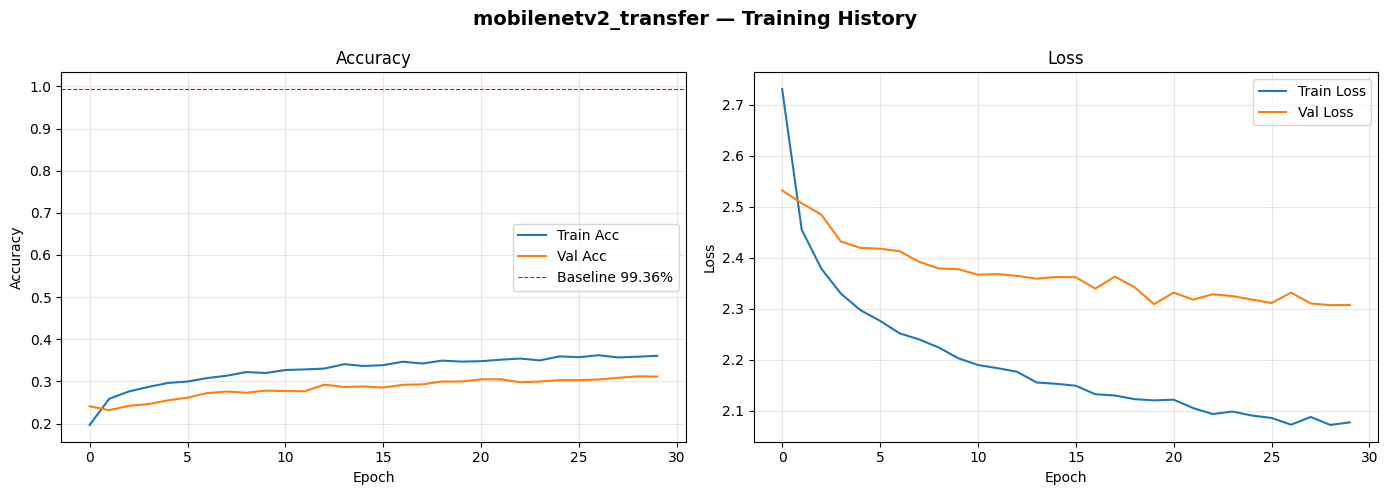

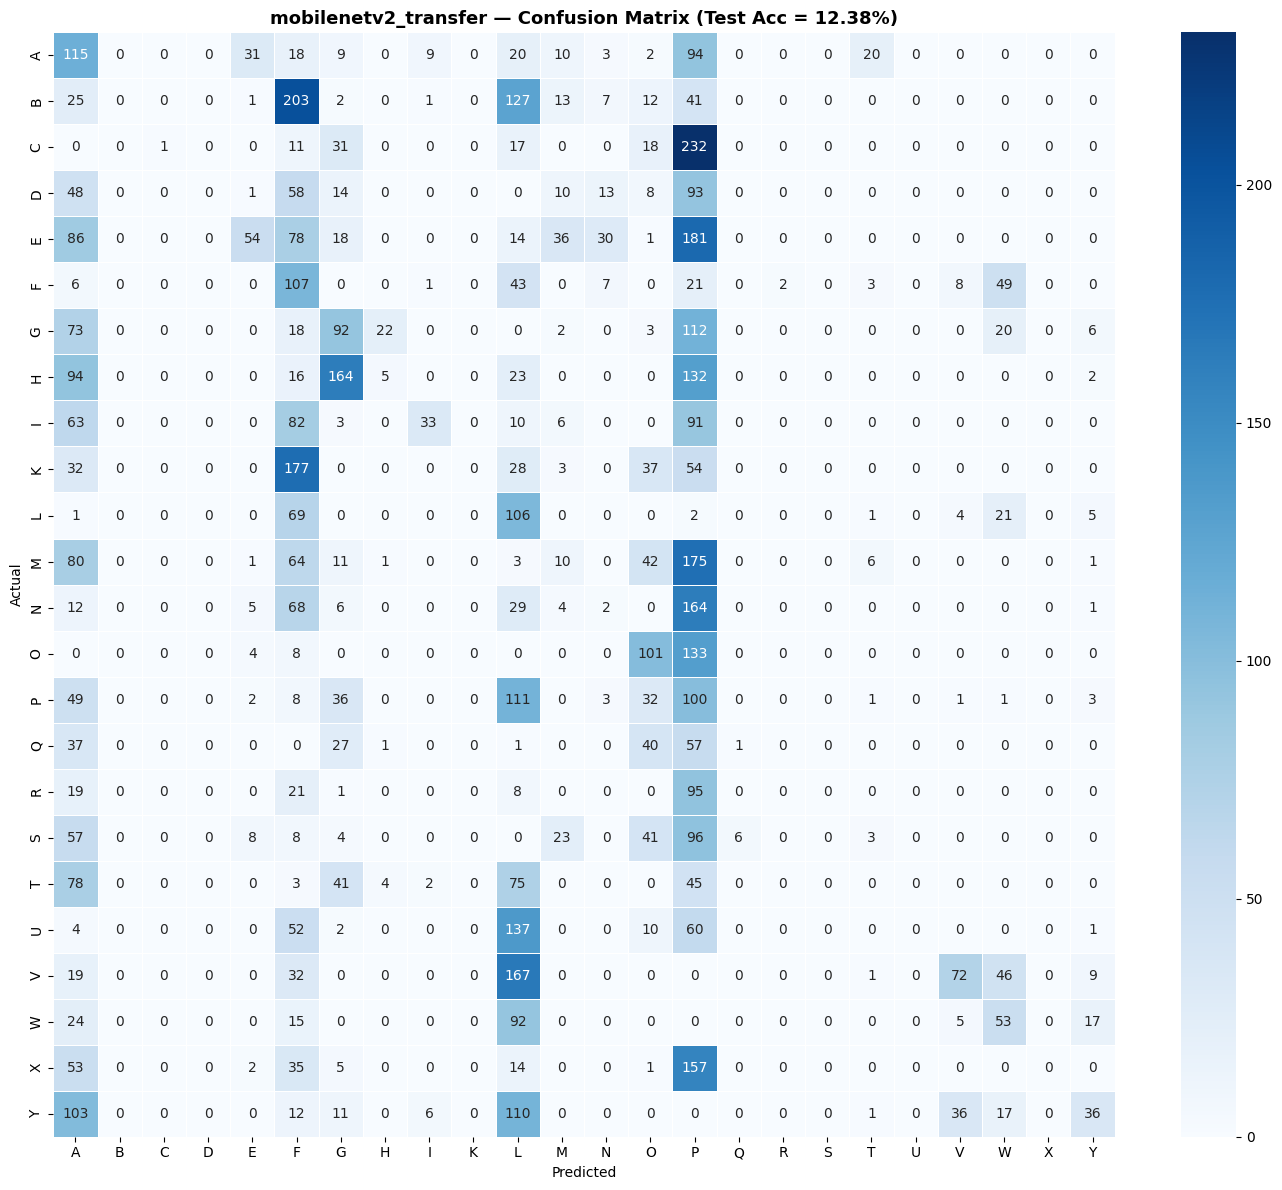


✅  Done! Outputs saved to ./outputs/mobilenetv2_transfer/
📊  TensorBoard:  tensorboard --logdir=logs/mobilenetv2_transfer


In [10]:
# ── 9. Plots ──────────────────────────────────────────────
# Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{MODEL_NAME} — Training History", fontsize=14, fontweight="bold")

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].axhline(0.9936, color="red", linestyle="--", linewidth=0.8, label="Baseline 99.36%")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test_idx, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, ax=ax)
ax.set_title(f"{MODEL_NAME} — Confusion Matrix (Test Acc = {acc*100:.2f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print(f"\n✅  Done! Outputs saved to ./{OUTPUT_DIR}/")
print(f"📊  TensorBoard:  tensorboard --logdir=logs/{MODEL_NAME}")

In [11]:
# ── 10. (Optional) Quick Results Table ────────────────────
# Run this cell after you've finished ALL experiments to
# compare models side-by-side.  Fill in your own results!

results = {
    "Model":         ["baseline_cnn", "residual_cnn", "depthwise_cnn",
                      "inception_cnn", "se_cnn", "densenet_cnn", "mobilenetv2_transfer"],
    "Params (K)":    [442, None, None, None, None, None, None],
    "Test Acc (%)":  [99.36, None, None, None, None, None, None],
    "Test Loss":     [0.0472, None, None, None, None, None, None],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print("\n→ Fill in the None values as you run each model.")

               Model  Params (K)  Test Acc (%)  Test Loss
        baseline_cnn       442.0         99.36     0.0472
        residual_cnn         NaN           NaN        NaN
       depthwise_cnn         NaN           NaN        NaN
       inception_cnn         NaN           NaN        NaN
              se_cnn         NaN           NaN        NaN
        densenet_cnn         NaN           NaN        NaN
mobilenetv2_transfer         NaN           NaN        NaN

→ Fill in the None values as you run each model.
